In [24]:
import requests
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

## Step 1: Import Shoreline Dataset

First of all, we need to read the Shoreline CSV file. If it is successful then it will display the first five rows. We will also clean the data to fix the date times

In [4]:
#Download shoreline dataset from Dyad repository
url = "https://doi.org/10.5061/dryad.70rxwdcd4"  #Manually download the dataset here  
file_name = "Narrabeen_Shoreline_Dataset_v1.csv"  #This is the filename you want - click on it and download
file_path = r'C:\ADD_PATH_HERE' # USER NEEDS TO MANUALLY CHANGE THIS TO THE CORRECT PATH

# Build full file path
file_join = os.path.join(file_path, file_name)

# --- Catch if file not found ---
if not os.path.exists(file_join):
    raise FileNotFoundError(
        f"\nFile not found: {file_join}\n\n"
        "Please:\n"
        "1. Download the dataset from the Dryad link above\n"
        "2. Update 'file_path' to the folder where the CSV is saved\n"
        "3. Make sure the filename matches exactly\n"
    )

# Read the CSV file
df = pd.read_csv(file_join)

# Fill missing Time (AEST) values with "00:00"
df['Time (AEST)'] = df['Time (AEST)'].fillna('00:00')

#Join date and time
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time (AEST)'], format='%d-%m-%Y %H:%M')
df.set_index('DateTime', inplace=True)

#Show the first 5 rows
df.head()

,RowID,Alongshore location s (m),Shoreline position p (m),Survey method,Eastings (m) (EPSG:28356),Northings (m) (EPSG:28356),Date,Time (AEST),Bias (m),Std (m),RMSE (m),Flag
DateTime,,,,,,,,,,,,
1930-03-06 11:59:00,0,100,36.92,AIRPHOTO,343146.43,6269419.04,06-03-1930,11:59,0.0,5.0,5.0,2
1930-03-06 11:59:00,1,104,36.13,AIRPHOTO,343143.63,6269416.07,06-03-1930,11:59,0.0,5.0,5.0,2
1930-03-06 11:59:00,2,108,35.35,AIRPHOTO,343140.84,6269413.10,06-03-1930,11:59,0.0,5.0,5.0,2
1930-03-06 11:59:00,3,112,34.57,AIRPHOTO,343138.05,6269410.13,06-03-1930,11:59,0.0,5.0,5.0,2
1930-03-06 11:59:00,4,116,33.79,AIRPHOTO,343135.26,6269407.15,06-03-1930,11:59,0.0,5.0,5.0,2


In [5]:
# Get the survey method names

survey_methods = df['Survey method'].unique()
print(survey_methods)

['AIRPHOTO' 'EMERYPFS' 'COASTSAT' 'ARGUS' 'RTKPFS' 'QUADBIKE' 'ARGUSNN'
 'NEARMAP' 'AIRLIDAR' 'FIXEDLIDAR' 'PLANETSCOPE' 'COASTSNAP' 'RTKSTORM']



## Example 1: Near-daily Argus shoreline data compared with in-situ RTK-GPS (Profile 6)

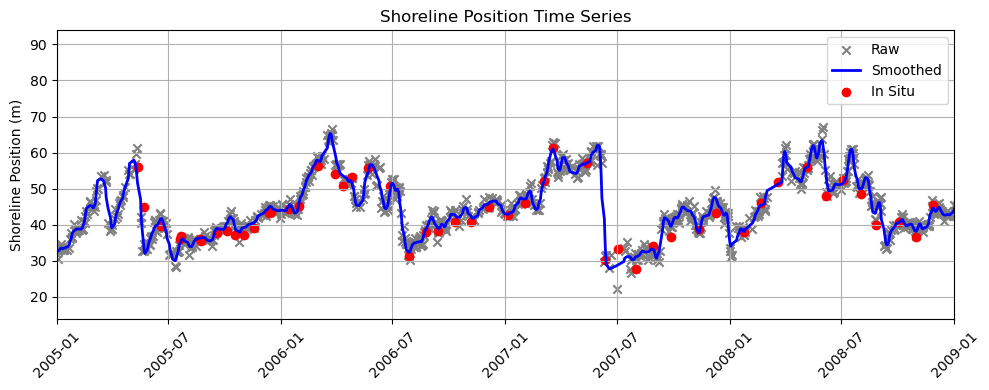

In [13]:
# Filter data for specific alongshore location and survey method

alongshore_location = 2604 
survey_method = 'ARGUS' # ARGUS survey method. Note that this method extends from alongshore_location> 2000 m only
filtered_df = df[(df['Alongshore location s (m)'] == alongshore_location) & (df['Survey method'] == survey_method)]

# Now plot the data
plt.figure(figsize=(10, 4))  # Set the size of the plot
plt.scatter(filtered_df.index, filtered_df['Shoreline position p (m)'], label='Raw', marker='x', color='grey')

# Smoooth the data using a butterworth filter
def butter_lowpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff / nyquist  # Normalized cutoff frequency
    b, a = butter(order, normal_cutoff, btype='low', analog=False)  # Filter coefficients
    return b, a

# Set smoothing filter parameters
cutoff = 0.1  # Cutoff frequency in Hz
fs = 1.0  # Sample rate (1 sample per day for this example)
order = 5  # Filter order

# Get the smoothing filter coefficients
b, a = butter_lowpass(cutoff, fs, order)

# Apply the soothing filter using filtfilt (zero-phase filtering)
smoothed_data = filtfilt(b, a, filtered_df['Shoreline position p (m)'])

# Plot smoothed data
plt.plot(filtered_df.index, smoothed_data, label='Smoothed', color='blue', linewidth=2)

# Add the GPS in situ measurements for comparison
survey_method = 'RTKPFS' # RTK profiles in situ
insitu_df = df[(df['Alongshore location s (m)'] == alongshore_location) & (df['Survey method'] == survey_method)]
plt.scatter(insitu_df.index, insitu_df['Shoreline position p (m)'], label='In Situ', marker='o', color='red')

# Set Date Limits
start_date = pd.to_datetime('2005-01-01')
end_date = pd.to_datetime('2009-01-01')
plt.xlim(pd.to_datetime(start_date), pd.to_datetime(end_date))

# Adding labels and title
plt.ylabel('Shoreline Position (m)')
plt.title('Shoreline Position Time Series')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display grid for better readability
plt.grid(True)
plt.legend()

# Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()


## Example 2: Plot before and after shorelines for 2007 Pasha Bulker storm on map

In [20]:
#Plot Shoreline on a map

import folium
import geopandas as gpd
from pyproj import Transformer

In [17]:
utm_zone = "EPSG:28356" # CRS of datsaset is GDA94/ MGA Zone 56 

survey_method = 'QUADBIKE'
shoreline_date1 = '14-05-2007' # Pre Pasha Bulker storm survey
shoreline_date2 = '12-06-2007' # Post Pasha Bulker storm survey
filtered_df1 = df[(df['Date'] == shoreline_date1) & (df['Survey method'] == survey_method)]
filtered_df2 = df[(df['Date'] == shoreline_date2) & (df['Survey method'] == survey_method)]
filtered_df1 = filtered_df1.reset_index(drop=True)
filtered_df2 = filtered_df2.reset_index(drop=True)

# Create a transformer to convert from UTM to WGS84 (latitude/longitude)
transformer = Transformer.from_crs(utm_zone, "EPSG:4326", always_xy=True)

# Apply the transformation to each row
df["Longitude"], df["Latitude"] = zip(*df.apply(lambda row: transformer.transform(row["Eastings (m) (EPSG:28356)"], row["Northings (m) (EPSG:28356)"]), axis=1))

In [21]:
# Create a Folium map centered at the first coordinate
map_osm = folium.Map(location=[filtered_df1["Latitude"].mean(), filtered_df1["Longitude"].mean()], zoom_start=12)

# Add points to the map
for idx, row in filtered_df1.iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=2,  # Size of marker
        color="red",
        fill=True,
        fill_color="red"
    ).add_to(map_osm)

# Add points to the map
for idx, row in filtered_df2.iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=2,  # Size of marker
        color="blue",
        fill=True,
        fill_color="red"
    ).add_to(map_osm)

# Display map
map_osm

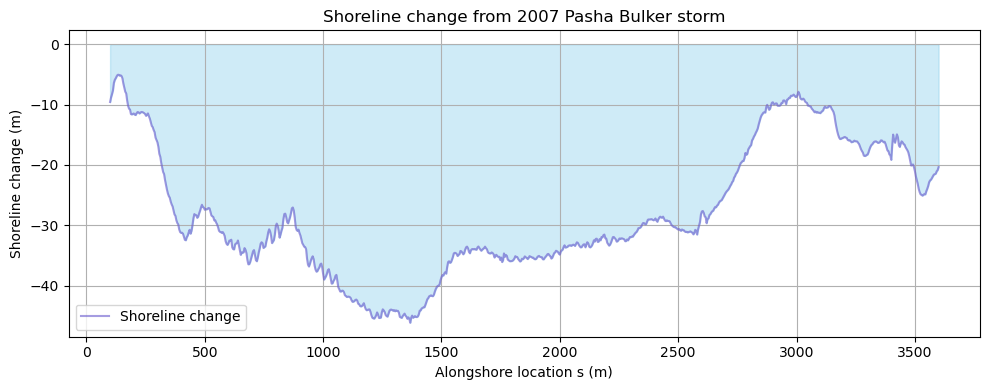

In [23]:
# Now plot the data
plt.figure(figsize=(10, 4))  # Set the size of the plot

# Create an area plot
plt.fill_between(filtered_df1['Alongshore location s (m)'], filtered_df2['Shoreline position p (m)']-filtered_df1['Shoreline position p (m)'], color='skyblue', alpha=0.4)  # Fill the area under the curve
plt.plot(filtered_df1['Alongshore location s (m)'], filtered_df2['Shoreline position p (m)']-filtered_df1['Shoreline position p (m)'], color='Slateblue', alpha=0.6, label = 'Shoreline change')  # Plot the line on top

# Adding labels and title
plt.xlabel('Alongshore location s (m)')
plt.ylabel('Shoreline change (m)')
plt.title('Shoreline change from 2007 Pasha Bulker storm')

# Display grid for better readability
plt.grid(True)
plt.legend()

# Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()